In [2]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from torchvision import datasets
from torch.utils.data import DataLoader

from rise.rise import RISE
from rise.rise_banzhaf import RISE_B
import rise.utils as utils
from rise.utils import IMAGES

## MNSIT DATA

### Load Data and Train Model

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.24MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 317kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.98MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.18MB/s]


In [4]:
class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1   = nn.Linear(64 * 7 * 7, 128)
        self.fc2   = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)      # 14x14
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)      # 7x7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [5]:
model = MNISTCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.2548
Epoch 2, Loss: 0.0603
Epoch 3, Loss: 0.0433


In [6]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        preds = output.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.986


In [50]:
def build_digit_example_dict(model, loader, device, max_samples=100):
    model.eval()

    digit_dict = {d: [] for d in range(10)}
    seen = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)

            for i in range(len(x)):
                seen += 1
                digit = y[i].item()

                if preds[i] == y[i]:  # only correct predictions
                    digit_dict[digit].append((x[i:i+1], y[i:i+1]))

                if seen >= max_samples:
                    break

            if seen >= max_samples:
                break

    return digit_dict

In [68]:
examples = build_digit_example_dict(model, test_loader, device)

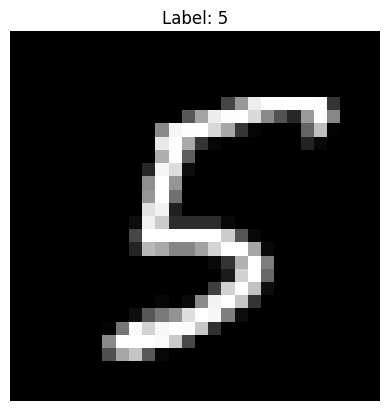

In [69]:
img_x, label = examples[5][2]

plt.imshow(img_x.squeeze().cpu(), cmap="gray")
plt.title(f"Label: {label.item()}")
plt.axis("off")
plt.show()

In [60]:
rise_banzhaf = RISE_B(model, img_x)
rise_banzhaf.generate_masks(N=20, s=7, p=0.5)

In [ ]:
sal = rise_banzhaf.forward(img_x)

Banzhaf sampling: 100%|██████████| 20/20 [00:00<00:00, 244.41it/s]

Total forward passes: 503


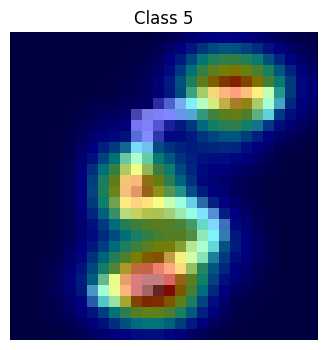

In [79]:
utils.draw_saliency_overlay_mnist(img_x, sal, class_id=5)

In [73]:
rise = RISE(model, img_x)
rise.generate_masks(N=7000, s=28, p=0.1)

Generating filters: 100%|██████████| 7000/7000 [00:00<00:00, 13577.48it/s]


In [74]:
sal_rise = rise.forward(img_x)

Running model: 100%|██████████| 70/70 [00:00<00:00, 811.13it/s]


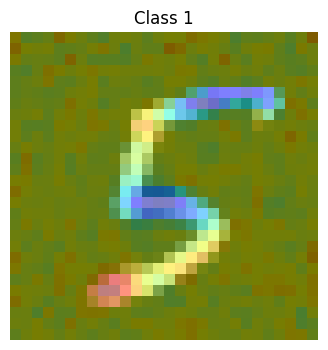

In [80]:
utils.draw_saliency_overlay_mnist(img_x, sal_rise, class_id=1)

## Exact Banzhaf

In [82]:
from rise.exact_banzhaf import build_supergrid_mask, exact_banzhaf_supergrid

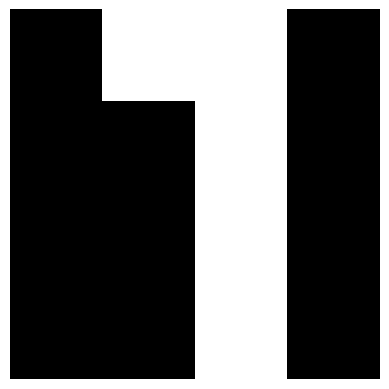

In [83]:
utils.draw_mask(build_supergrid_mask(torch.tensor([0,1,1,0, 
                                                   0,0,1,0, 
                                                   0,0,1,0, 
                                                   0,0,1,0]), 4))

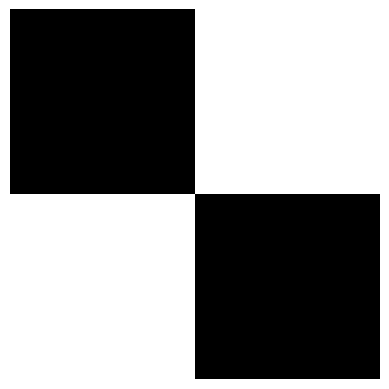

In [84]:
utils.draw_mask(build_supergrid_mask(torch.tensor([0,1, 
                                                   1,0]), 2))

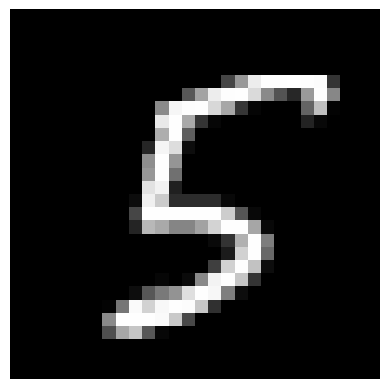

In [85]:
plt.imshow(img_x.cpu().squeeze().numpy(), cmap="gray")
plt.axis("off")
plt.show()

In [86]:
model(img_x) # should be class 1 with high confidence, it is..

tensor([[ -5.7527, -13.4021,  -8.6525,   0.2997,  -3.2068,  12.5188,   2.8135,
          -9.3922,  -2.3683,   1.3679]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [88]:
beta = exact_banzhaf_supergrid(model, img_x, s=4)

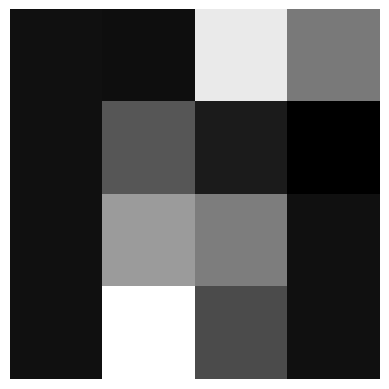

In [94]:
utils.draw_mask(beta[5])

In [90]:
# do banzhaf approx
rise_banzhaf = RISE_B(model, img_x)
rise_banzhaf.generate_masks(N=500, s=4, p=0.5)

In [91]:
sal = rise_banzhaf.forward(img_x)

Banzhaf sampling: 100%|██████████| 500/500 [00:00<00:00, 614.14it/s]

Total forward passes: 4451


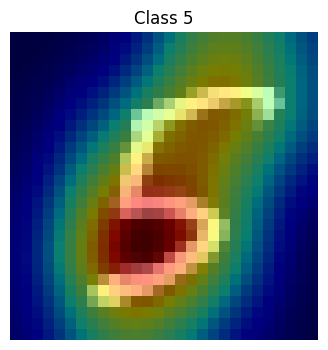

In [93]:
utils.draw_saliency_overlay_mnist(img_x, sal, class_id=5)

In [95]:
rise = RISE(model, img_x)
rise.generate_masks(N=5000, s=4, p=0.1)

Generating filters: 100%|██████████| 5000/5000 [00:00<00:00, 7016.29it/s]


In [96]:
sal_rise = rise.forward(img_x)

Running model: 100%|██████████| 50/50 [00:00<00:00, 3848.97it/s]


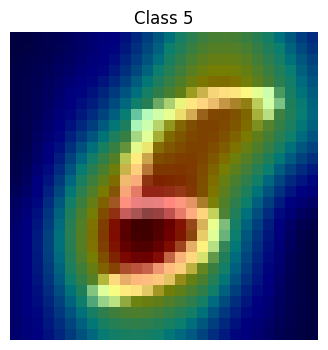

In [98]:
utils.draw_saliency_overlay_mnist(img_x, sal_rise, class_id=5)